## **Analisis Pengaruh Pengguna Internet terhadap Indeks Pembangunan Manusia (IPM) di Indonesia dengan Kontrol PDRB per Kapita**

### **Anggota Kelompok**
1.   Tamaela Nurandyapasa (24031554044)
2.   Annisa Ramadhani (24031554206)



File Dataset (Raw Data)

1.   Pengguna Internet Tahun 2017 : https://drive.google.com/file/d/1iHJZdYk5Yubu6ncUIQ5-FuSk3qkvc0hX/view?usp=drive_link
1.   Pengguna Internet Tahun 2018 : https://drive.google.com/file/d/1nEjHBn2YEnNA3dQ4AvJVSj-3SwH2qXgl/view?usp=drive_link
1.   Pengguna Internet Tahun 2019 : https://drive.google.com/file/d/1j93LiRue1DfSjMy5qVkzwKj3ipSZYpd6/view?usp=drive_link
2.   Index Pembangunan Manusia Tahun 2017-2019 : https://drive.google.com/file/d/16LrtfjeRgbZFPjT4JkjtguKg_LoSbP0w/view?usp=drive_link
2.   Produk Domestik Regional Bruto 2016-2024 : https://drive.google.com/file/d/1zKu8pT6HMIcfRPFcOaOjSTy7-Kt3D2ua/view?usp=drive_link



## **Baca file dan simpan ke directory**

In [3]:
!pip install gdown
import pandas as pd
import gdown

In [4]:
file_ids = {
    "internet_2017": "1iHJZdYk5Yubu6ncUIQ5-FuSk3qkvc0hX",
    "internet_2018": "1nEjHBn2YEnNA3dQ4AvJVSj-3SwH2qXgl",
    "internet_2019": "1j93LiRue1DfSjMy5qVkzwKj3ipSZYpd6",
    "ipm_2017_2019": "16LrtfjeRgbZFPjT4JkjtguKg_LoSbP0w",
    "pdrb_2016_2024": "1zKu8pT6HMIcfRPFcOaOjSTy7-Kt3D2ua"
}

In [5]:
def load_csv(file_id, filename):
    url = f"https://drive.google.com/uc?export=download&id={file_id}"
    print(f"\nDownloading {filename} ...")

    gdown.download(url, filename, quiet=False)

    df = pd.read_csv(filename)
    return df

In [6]:
data = {
    "internet_2017": load_csv(file_ids["internet_2017"], "internet_2017.csv"),
    "internet_2018": load_csv(file_ids["internet_2018"], "internet_2018.csv"),
    "internet_2019": load_csv(file_ids["internet_2019"], "internet_2019.csv"),
    "ipm_2017_2019": load_csv(file_ids["ipm_2017_2019"], "ipm_2017_2019.csv"),
    "pdrb_2016_2024": load_csv(file_ids["pdrb_2016_2024"], "pdrb_2016_2024.csv"),
}

Downloading...
From: https://drive.google.com/uc?export=download&id=1iHJZdYk5Yubu6ncUIQ5-FuSk3qkvc0hX
To: /content/internet_2017.csv
100%|██████████| 818/818 [00:00<00:00, 2.22MB/s]


Downloading...
From: https://drive.google.com/uc?export=download&id=1nEjHBn2YEnNA3dQ4AvJVSj-3SwH2qXgl
To: /content/internet_2018.csv
100%|██████████| 817/817 [00:00<00:00, 1.82MB/s]


Downloading...
From: https://drive.google.com/uc?export=download&id=1j93LiRue1DfSjMy5qVkzwKj3ipSZYpd6
To: /content/internet_2019.csv
100%|██████████| 817/817 [00:00<00:00, 3.03MB/s]


Downloading...
From: https://drive.google.com/uc?export=download&id=16LrtfjeRgbZFPjT4JkjtguKg_LoSbP0w
To: /content/ipm_2017_2019.csv
100%|██████████| 2.38k/2.38k [00:00<00:00, 7.47MB/s]


Downloading...
From: https://drive.google.com/uc?export=download&id=1zKu8pT6HMIcfRPFcOaOjSTy7-Kt3D2ua
To: /content/pdrb_2016_2024.csv
100%|██████████| 14.8k/14.8k [00:00<00:00, 26.8MB/s]


## **Cleaning, Formatting dan Integrasi Data tiap 1 Dataset**

#### **Cleaning dan Integrasi Data Internet 2017, 2018, 2019**

In [7]:
import pandas as pd

def load_and_clean_csv(path, year):
    df = pd.read_csv(path)

    df = df.iloc[2:].reset_index(drop=True)
    df.columns = ["nama_provinsi", "persentase_internet"]
    df = df.sort_values("nama_provinsi")
    df["tahun"] = year

    return df

In [8]:
df_2017 = load_and_clean_csv("/content/internet_2017.csv", 2017)
df_2018 = load_and_clean_csv("/content/internet_2018.csv", 2018)
df_2019 = load_and_clean_csv("/content/internet_2019.csv", 2019)

df_final = pd.concat([df_2017, df_2018, df_2019], ignore_index=True)
df_final = df_final.sort_values(["nama_provinsi", "tahun"]).reset_index(drop=True)

df_final["nama_provinsi"] = df_final["nama_provinsi"].replace({
    "KEP. BANGKA BELITUNG": "KEPULAUAN BANGKA BELITUNG",
    "KEP. RIAU": "KEPULAUAN RIAU"
})

output_path = "/content/pengguna_internet.csv"
df_final.to_csv(output_path, index=False)

output_path

'/content/pengguna_internet.csv'

In [9]:
df_final.head()

,nama_provinsi,persentase_internet,tahun
0,ACEH,22.86,2017
1,ACEH,30.69,2018
2,ACEH,35.6,2019
3,BALI,39.49,2017
4,BALI,46.42,2018


#### **Cleaning Data IPM**

In [10]:
import pandas as pd

df = pd.read_csv("/content/ipm_2017_2019.csv")
df = df[(df["Level"]=="Subnat") & (df["Region"]!="Total")].copy()

year_cols = [c for c in df.columns if any(y in str(c) for y in ["2017","2018","2019"])]
df2 = df[["Region"] + year_cols].copy()

mask = df2["Region"].str.contains("Riau", case=False) & df2["Region"].str.contains("Incl", case=False)
df_riau_merge = df2[mask].copy()

df2 = df2[~mask].copy()

df_riau = df_riau_merge.copy()
df_kepri = df_riau_merge.copy()

df_riau["Region"] = "Riau"
df_kepri["Region"] = "Kepulauan Riau"

df2 = pd.concat([df2, df_riau, df_kepri], ignore_index=True)

mapping = {
    "DI Aceh": "ACEH",
    "Aceh": "ACEH",
    "Bali": "BALI",
    "Bangka Belitung": "KEPULAUAN BANGKA BELITUNG",
    "Banten": "BANTEN",
    "Bengkulu": "BENGKULU",
    "Central Java": "JAWA TENGAH",
    "Central Kalimantan": "KALIMANTAN TENGAH",
    "Central Sulawesi": "SULAWESI TENGAH",
    "DI Yogyakarta": "DI YOGYAKARTA",
    "DKI Jakarta": "DKI JAKARTA",
    "East Java": "JAWA TIMUR",
    "East Kalimantan": "KALIMANTAN TIMUR",
    "East Nusa Tenggara": "NUSA TENGGARA TIMUR",
    "Gorontalo": "GORONTALO",
    "Jambi": "JAMBI",
    "Lampung": "LAMPUNG",
    "Maluku": "MALUKU",
    "North Kalimantan": "KALIMANTAN UTARA",
    "North Maluku": "MALUKU UTARA",
    "North Sulawesi": "SULAWESI UTARA",
    "North Sumatra": "SUMATERA UTARA",
    "Papua": "PAPUA",
    "Papua Barat": "PAPUA BARAT",
    "South Kalimantan": "KALIMANTAN SELATAN",
    "South Sulawesi": "SULAWESI SELATAN",
    "South Sumatra": "SUMATERA SELATAN",
    "Southeast Sulawesi": "SULAWESI TENGGARA",
    "West Java": "JAWA BARAT",
    "West Kalimantan": "KALIMANTAN BARAT",
    "West Nusa Tenggara": "NUSA TENGGARA BARAT",
    "West Papua": "PAPUA BARAT",
    "West Sulawesi": "SULAWESI BARAT",
    "West Sumatra": "SUMATERA BARAT",
    "Riau": "RIAU",
    "Kepulauan Riau": "KEPULAUAN RIAU",
}

df2["Region"] = df2["Region"].replace(mapping)
df2["Region"] = df2["Region"].str.upper()

df_long = df2.melt(id_vars="Region", var_name="tahun", value_name="ipm")
df_long["tahun"] = df_long["tahun"].str.extract(r"(\d{4})")[0].astype(int)
df_long["ipm"] = pd.to_numeric(df_long["ipm"], errors="coerce")
df_long = df_long.rename(columns={"Region":"nama_provinsi"})
df_long = df_long.sort_values(["nama_provinsi","tahun"]).reset_index(drop=True)

output_path = "/content/ipm.csv"
df_long.to_csv(output_path, index=False)

output_path

'/content/ipm.csv'

#### **Cleaning Data PDRB**

In [11]:
import pandas as pd

df = pd.read_csv("/content/pdrb_2016_2024.csv")

df_clean = df[["nama_provinsi", "pdrb_per_kapita", "tahun"]]

df_clean = df_clean.rename(columns={
    "pdrb_per_kapita": "pdrb_perkapita_dalam_ribu_rupiah"
})

df_clean = df_clean[df_clean["tahun"].isin([2017, 2018, 2019])]
df_clean = df_clean.sort_values(["nama_provinsi", "tahun"]).reset_index(drop=True)

output_path = "/content/pdrb.csv"
df_clean.to_csv(output_path, index=False)

output_path


'/content/pdrb.csv'

## **Integrasi/Merge 3 Dataset Menjadi 1**

In [12]:
import pandas as pd

internet = pd.read_csv("/content/pengguna_internet.csv")
ipm = pd.read_csv("/content/ipm.csv")
pdrb = pd.read_csv("/content/pdrb.csv")

internet["nama_provinsi"] = internet["nama_provinsi"].str.upper()
ipm["nama_provinsi"] = ipm["nama_provinsi"].str.upper()
pdrb["nama_provinsi"] = pdrb["nama_provinsi"].str.upper()

df = pd.merge(internet, ipm, on=["nama_provinsi", "tahun"], how="left")
df = pd.merge(df, pdrb, on=["nama_provinsi", "tahun"], how="left")

df = df.sort_values(["nama_provinsi", "tahun"]).reset_index(drop=True)

output_path = "/content/merge_dataset.csv"
df.to_csv(output_path, index=False)

output_path

'/content/merge_dataset.csv'

## **Investigation**

In [13]:
import pandas as pd
df = pd.read_csv("/content/merge_dataset.csv")

df = df[df["nama_provinsi"].str.upper() != "INDONESIA"]

df = df.replace(r'^\s*$', pd.NA, regex=True)
df = df.replace(r'^\s*-\s*$', pd.NA, regex=True)

df = df[[
    "nama_provinsi",
    "tahun",
    "persentase_internet",
    "ipm",
    "pdrb_perkapita_dalam_ribu_rupiah"
]]

In [14]:
df.isna().sum()

,0
nama_provinsi,0
tahun,0
persentase_internet,12
ipm,30
pdrb_perkapita_dalam_ribu_rupiah,12


In [15]:
output_path = "/content/final_dataset.csv"
df.to_csv(output_path, index=False)

output_path

'/content/final_dataset.csv'

## **Data Eksplorasi**

In [16]:
df = pd.read_csv("/content/final_dataset.csv")

#### **Exploring Table**

In [17]:
import numpy as np
import pandas as pd

In [18]:
df.head()

,nama_provinsi,tahun,persentase_internet,ipm,pdrb_perkapita_dalam_ribu_rupiah
0,ACEH,2017,22.86,0.717,28096.71
1,ACEH,2018,30.69,0.720,29521.25
2,ACEH,2019,35.60,0.719,30879.06
3,BALI,2017,39.49,0.738,50167.07
4,BALI,2018,46.42,0.740,54433.46


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 5 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   nama_provinsi                     114 non-null    object 
 1   tahun                             114 non-null    int64  
 2   persentase_internet               102 non-null    float64
 3   ipm                               84 non-null     float64
 4   pdrb_perkapita_dalam_ribu_rupiah  102 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 4.6+ KB


In [20]:
df.columns

Index(['nama_provinsi', 'tahun', 'persentase_internet', 'ipm',
       'pdrb_perkapita_dalam_ribu_rupiah'],
      dtype='object')

In [21]:
df_sorted = df.sort_values(by='ipm', ascending=False)
df_sorted.head()

,nama_provinsi,tahun,persentase_internet,ipm,pdrb_perkapita_dalam_ribu_rupiah
17,DKI JAKARTA,2019,73.46,0.768,268052.25
16,DKI JAKARTA,2018,65.89,0.768,247678.49
13,DI YOGYAKARTA,2018,55.45,0.765,34136.93
15,DKI JAKARTA,2017,60.65,0.765,228002.73
14,DI YOGYAKARTA,2019,61.73,0.764,36459.73


In [22]:
df.describe()

,tahun,persentase_internet,ipm,pdrb_perkapita_dalam_ribu_rupiah
count,114.000000,102.000000,84.000000,102.000000
mean,2018.000000,37.382549,0.713155,59669.557451
std,0.820101,11.543402,0.022897,46003.977947
min,2017.000000,16.510000,0.658000,17165.450000
25%,2017.000000,28.987500,0.700000,35228.620000
50%,2018.000000,36.405000,0.712000,47068.580000
75%,2019.000000,44.705000,0.725250,57042.950000
max,2019.000000,73.460000,0.768000,268052.250000


In [23]:
df[['ipm', 'persentase_internet', 'pdrb_perkapita_dalam_ribu_rupiah']].agg(['min', 'max', 'mean', 'median'])

,ipm,persentase_internet,pdrb_perkapita_dalam_ribu_rupiah
min,0.658000,16.510000,17165.450000
max,0.768000,73.460000,268052.250000
mean,0.713155,37.382549,59669.557451
median,0.712000,36.405000,47068.580000


In [24]:
df[df.isna().any(axis=1)].head()

,nama_provinsi,tahun,persentase_internet,ipm,pdrb_perkapita_dalam_ribu_rupiah
45,KALIMANTAN UTARA,2017,36.40,NaN,111318.54
46,KALIMANTAN UTARA,2018,46.87,NaN,119413.88
47,KALIMANTAN UTARA,2019,54.30,NaN,138751.01
60,MALUKU UTARA,2017,18.80,NaN,26686.06
61,MALUKU UTARA,2018,25.80,NaN,29586.12


In [25]:
cols = ["nama_provinsi",
        "persentase_internet",
        "ipm",
        "pdrb_perkapita_dalam_ribu_rupiah"]

print("🔵 5 Provinsi dengan Persentase Internet Tertinggi")
display(df.nlargest(5, "persentase_internet")[["nama_provinsi", "persentase_internet"]])

print("🔵 5 Provinsi dengan Persentase Internet Terendah")
display(df.nsmallest(5, "persentase_internet")[["nama_provinsi", "persentase_internet"]])

print("🟢 5 Provinsi dengan IPM Tertinggi")
display(df.nlargest(5, "ipm")[["nama_provinsi", "ipm"]])

print("🟢 5 Provinsi dengan IPM Terendah")
display(df.nsmallest(5, "ipm")[["nama_provinsi", "ipm"]])

print("🟣 5 Provinsi dengan PDRB per Kapita Tertinggi")
display(df.nlargest(5, "pdrb_perkapita_dalam_ribu_rupiah")
        [["nama_provinsi", "pdrb_perkapita_dalam_ribu_rupiah"]])

print("🟣 5 Provinsi dengan PDRB per Kapita Terendah")
display(df.nsmallest(5, "pdrb_perkapita_dalam_ribu_rupiah")
        [["nama_provinsi", "pdrb_perkapita_dalam_ribu_rupiah"]])


🔵 5 Provinsi dengan Persentase Internet Tertinggi


,nama_provinsi,persentase_internet
17,DKI JAKARTA,73.46
16,DKI JAKARTA,65.89
53,KEPULAUAN RIAU,65.02
14,DI YOGYAKARTA,61.73
15,DKI JAKARTA,60.65


🔵 5 Provinsi dengan Persentase Internet Terendah


,nama_provinsi,persentase_internet
69,PAPUA,16.51
66,NUSA TENGGARA TIMUR,17.88
60,MALUKU UTARA,18.80
90,SULAWESI BARAT,19.50
70,PAPUA,19.59


🟢 5 Provinsi dengan IPM Tertinggi


...

,nama_provinsi,ipm
66,NUSA TENGGARA TIMUR,0.658
68,NUSA TENGGARA TIMUR,0.660
67,NUSA TENGGARA TIMUR,0.661
18,GORONTALO,0.674
20,GORONTALO,0.675


🟣 5 Provinsi dengan PDRB per Kapita Tertinggi


,nama_provinsi,pdrb_perkapita_dalam_ribu_rupiah
17,DKI JAKARTA,268052.25
16,DKI JAKARTA,247678.49
15,DKI JAKARTA,228002.73
44,KALIMANTAN TIMUR,180259.10
43,KALIMANTAN TIMUR,174164.82


🟣 5 Provinsi dengan PDRB per Kapita Terendah


,nama_provinsi,pdrb_perkapita_dalam_ribu_rupiah
66,NUSA TENGGARA TIMUR,17165.45
67,NUSA TENGGARA TIMUR,18417.54
68,NUSA TENGGARA TIMUR,19630.02
57,MALUKU,22859.29
58,MALUKU,24268.62


#### **KNN Imputer**

In [26]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors= 10)
X = df[['ipm', 'persentase_internet', 'pdrb_perkapita_dalam_ribu_rupiah']]
pd.DataFrame(imputer.fit_transform(X))

,0,1,2
0,0.717,22.86,28096.71
1,0.720,30.69,29521.25
2,0.719,35.60,30879.06
3,0.738,39.49,50167.07
4,0.740,46.42,54433.46
...,...,...,...
109,0.707,33.35,50104.67
110,0.706,38.14,53359.10
111,0.719,27.63,48003.60
112,0.721,34.27,51427.49


In [27]:
from sklearn.impute import KNNImputer
import pandas as pd

cols_impute = ['ipm', 'persentase_internet', 'pdrb_perkapita_dalam_ribu_rupiah']
X = df[cols_impute]

imputer = KNNImputer(n_neighbors=10)
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=cols_impute)

df_final = df.copy()
df_final[cols_impute] = X_imputed

df_final.to_csv("/content/finaldatasetimputer.csv", index=False)

df = df_final.copy()

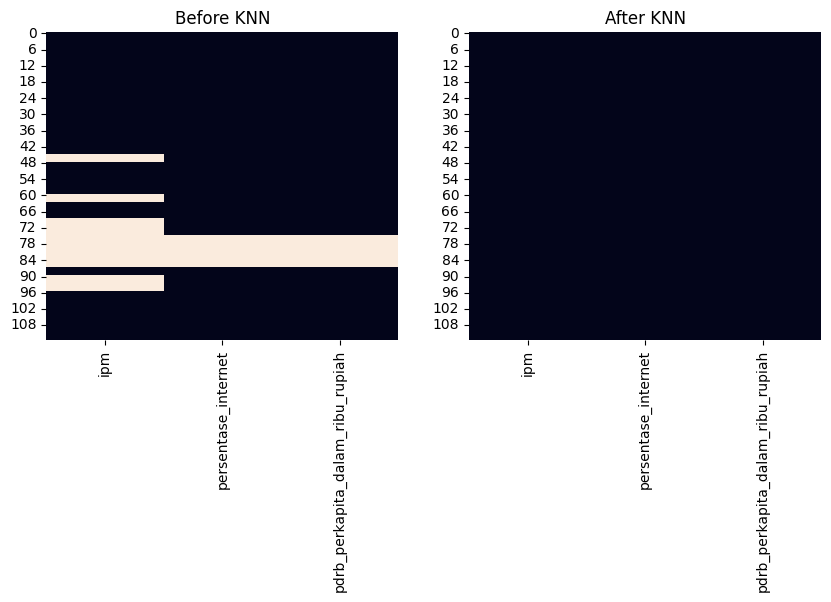

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2, figsize=(10,4))

sns.heatmap(X.isna(), cbar=False, ax=ax[0])
ax[0].set_title("Before KNN")

sns.heatmap(X_imputed.isna(), cbar=False, ax=ax[1])
ax[1].set_title("After KNN")

plt.show()

#### **Finding Outlier**

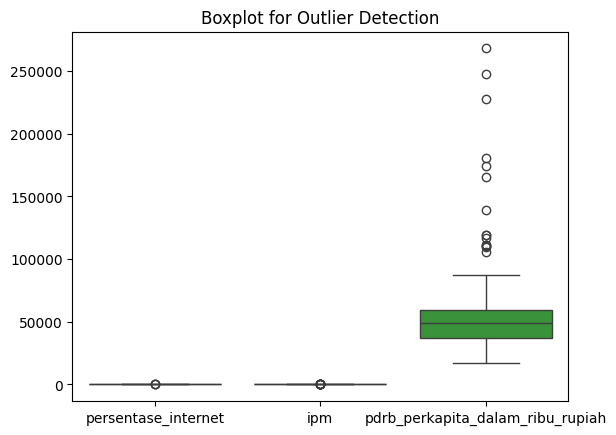

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df[["persentase_internet","ipm","pdrb_perkapita_dalam_ribu_rupiah"]])
plt.title("Boxplot for Outlier Detection")
plt.show()

#### **Plotting**

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

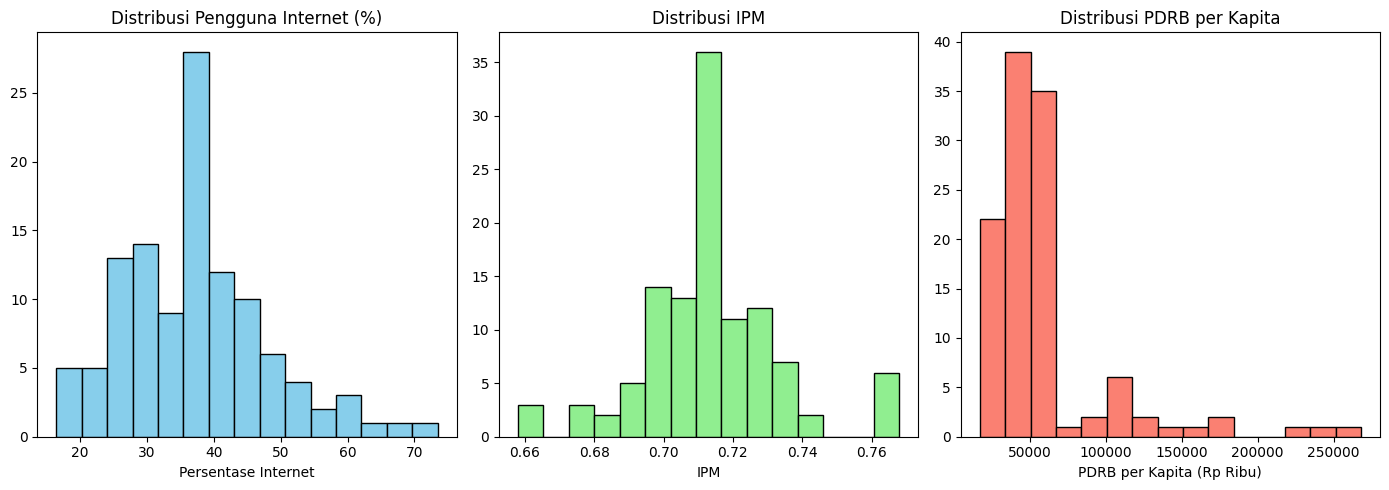

In [31]:
plt.figure(figsize=(14,5))

plt.subplot(1,3,1)
plt.hist(df["persentase_internet"], bins=15, color='skyblue', edgecolor='black')
plt.title("Distribusi Pengguna Internet (%)")
plt.xlabel("Persentase Internet")

plt.subplot(1,3,2)
plt.hist(df["ipm"], bins=15, color='lightgreen', edgecolor='black')
plt.title("Distribusi IPM")
plt.xlabel("IPM")

plt.subplot(1,3,3)
plt.hist(df["pdrb_perkapita_dalam_ribu_rupiah"], bins=15, color='salmon', edgecolor='black')
plt.title("Distribusi PDRB per Kapita")
plt.xlabel("PDRB per Kapita (Rp Ribu)")

plt.tight_layout()
plt.show()

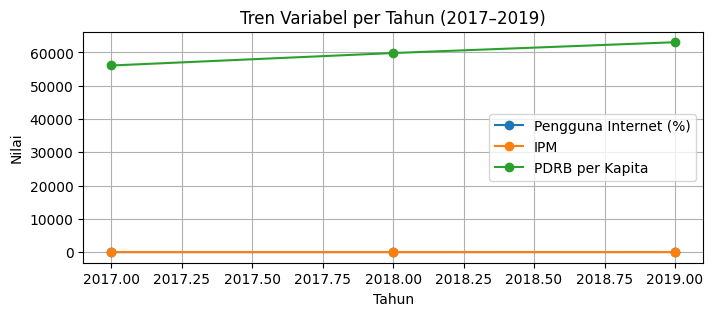

In [32]:
trend = df.groupby("tahun").mean(numeric_only=True)

plt.figure(figsize=(8,3))
plt.plot(trend.index, trend["persentase_internet"], marker="o", label="Pengguna Internet (%)")
plt.plot(trend.index, trend["ipm"], marker="o", label="IPM")
plt.plot(trend.index, trend["pdrb_perkapita_dalam_ribu_rupiah"], marker="o", label="PDRB per Kapita")

plt.title("Tren Variabel per Tahun (2017–2019)")
plt.xlabel("Tahun")
plt.ylabel("Nilai")
plt.grid(True)
plt.legend()
plt.show()

#### **Korelasi antar variabel**

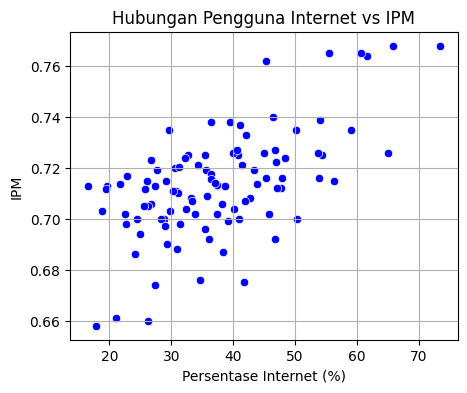

In [33]:
plt.figure(figsize=(5,4))
sns.scatterplot(data=df, x="persentase_internet", y="ipm", color="blue")
plt.title("Hubungan Pengguna Internet vs IPM")
plt.xlabel("Persentase Internet (%)")
plt.ylabel("IPM")
plt.grid(True)
plt.show()

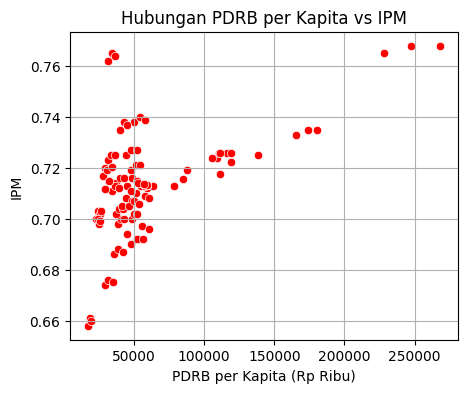

In [34]:
plt.figure(figsize=(5,4))
sns.scatterplot(data=df,
                x="pdrb_perkapita_dalam_ribu_rupiah",
                y="ipm",
                color="red")
plt.title("Hubungan PDRB per Kapita vs IPM")
plt.xlabel("PDRB per Kapita (Rp Ribu)")
plt.ylabel("IPM")
plt.grid(True)
plt.show()

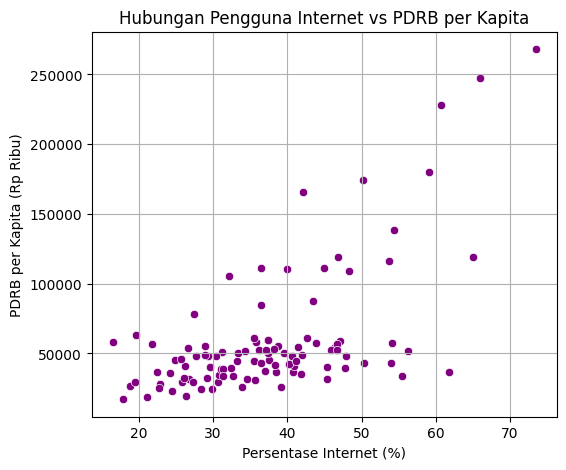

In [35]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x="persentase_internet", y="pdrb_perkapita_dalam_ribu_rupiah", color="purple")
plt.title("Hubungan Pengguna Internet vs PDRB per Kapita")
plt.xlabel("Persentase Internet (%)")
plt.ylabel("PDRB per Kapita (Rp Ribu)")
plt.grid(True)
plt.show()

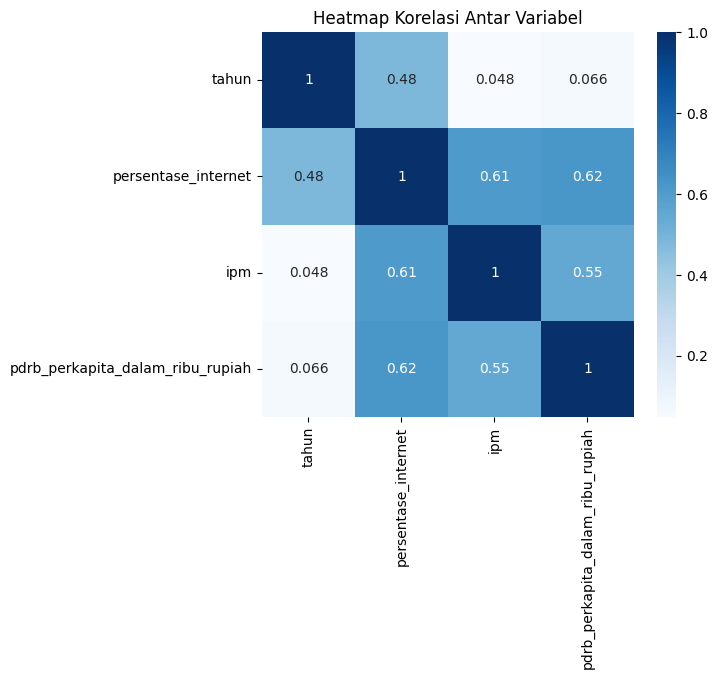

In [36]:
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")
plt.title("Heatmap Korelasi Antar Variabel")
plt.show()

## **Regresi & Kesimpulan Hasil Analis**

In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

df = pd.read_csv("/content/finaldatasetimputer.csv")

In [38]:
cols = ["persentase_internet", "ipm", "pdrb_perkapita_dalam_ribu_rupiah"]
df[cols] = df[cols].apply(pd.to_numeric, errors="coerce")
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=cols).reset_index(drop=True)


=== MODEL 1 ===
                            OLS Regression Results                            
Dep. Variable:                    ipm   R-squared:                       0.368
Model:                            OLS   Adj. R-squared:                  0.362
Method:                 Least Squares   F-statistic:                     65.25
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           8.36e-13
Time:                        20:16:07   Log-Likelihood:                 312.46
No. Observations:                 114   AIC:                            -620.9
Df Residuals:                     112   BIC:                            -615.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const            

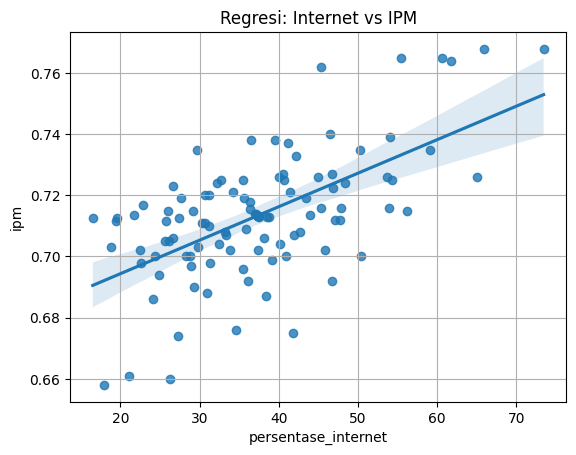

In [39]:
X1 = sm.add_constant(df[["persentase_internet"]])
y = df["ipm"]
model1 = sm.OLS(y, X1).fit()
print("\n=== MODEL 1 ===")


print(model1.summary())

sns.regplot(data=df, x="persentase_internet", y="ipm")
plt.title("Regresi: Internet vs IPM")
plt.grid(True)
plt.show()

## **INTERPRETASI MODEL 1**

In [40]:
coef = model1.params["persentase_internet"]
pval = model1.pvalues["persentase_internet"]
r2 = model1.rsquared
intercept = model1.params["const"]

print("=== INTERPRETASI MODEL 1 ===\n")

print(f"R-squared: {r2:.3f}")
print(f"Koefisien Internet: {coef:.5f}")
print(f"p-value: {pval:.5f}")
print(f"Intercept: {intercept:.5f}\n")

interpre = f"""
Berdasarkan Model 1 (Internet → IPM):
1. Nilai R-squared sebesar {r2:.3f} menunjukkan bahwa sekitar {r2*100:.1f}% variasi dalam IPM
   dapat dijelaskan oleh variabel persentase pengguna internet.
2. Koefisien regresi sebesar {coef:.5f} bernilai positif, artinya:
   - setiap kenaikan 1% pengguna internet diprediksi akan meningkatkan IPM sebesar {coef:.5f}.
   - hal ini menunjukkan adanya hubungan positif antara penggunaan internet dan IPM.
3. Nilai p-value = {pval:.5f} (lebih kecil dari 0.05), sehingga:
   - pengaruh variabel internet terhadap IPM bersifat **signifikan secara statistik**.
   - dengan kata lain, internet memang berperan dalam peningkatan IPM.
4. Intercept sebesar {intercept:.5f} berarti:
   - ketika nilai internet = 0, IPM diperkirakan berada di sekitar {intercept:.5f},
     meskipun kondisi tersebut tidak realistis secara empiris.
Kesimpulan:
✔ Persentase pengguna internet memiliki pengaruh positif dan signifikan terhadap IPM.
✔ Daerah dengan penggunaan internet lebih tinggi cenderung memiliki kualitas pembangunan manusia yang lebih baik.
"""

print(interpre)

=== INTERPRETASI MODEL 1 ===

R-squared: 0.368
Koefisien Internet: 0.00110
p-value: 0.00000
Intercept: 0.67243


Berdasarkan Model 1 (Internet → IPM):
1. Nilai R-squared sebesar 0.368 menunjukkan bahwa sekitar 36.8% variasi dalam IPM
   dapat dijelaskan oleh variabel persentase pengguna internet.
2. Koefisien regresi sebesar 0.00110 bernilai positif, artinya:
   - setiap kenaikan 1% pengguna internet diprediksi akan meningkatkan IPM sebesar 0.00110.
   - hal ini menunjukkan adanya hubungan positif antara penggunaan internet dan IPM.
3. Nilai p-value = 0.00000 (lebih kecil dari 0.05), sehingga:
   - pengaruh variabel internet terhadap IPM bersifat **signifikan secara statistik**.
   - dengan kata lain, internet memang berperan dalam peningkatan IPM.
4. Intercept sebesar 0.67243 berarti:
   - ketika nilai internet = 0, IPM diperkirakan berada di sekitar 0.67243,
     meskipun kondisi tersebut tidak realistis secara empiris.
Kesimpulan:
✔ Persentase pengguna internet memiliki pengaruh pos


=== MODEL 2 ===
                            OLS Regression Results                            
Dep. Variable:                    ipm   R-squared:                       0.302
Model:                            OLS   Adj. R-squared:                  0.296
Method:                 Least Squares   F-statistic:                     48.53
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           2.36e-10
Time:                        20:16:07   Log-Likelihood:                 306.82
No. Observations:                 114   AIC:                            -609.6
Df Residuals:                     112   BIC:                            -604.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------

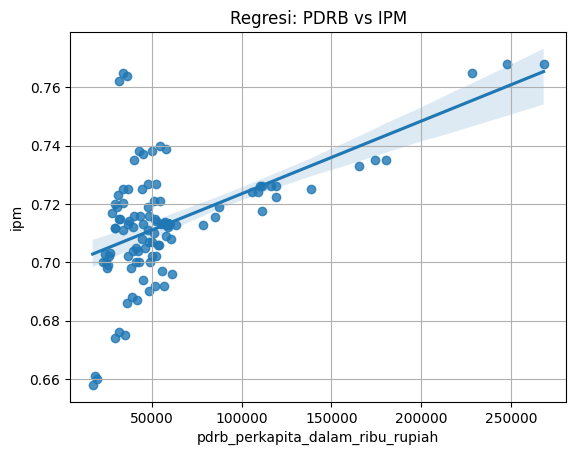

In [41]:
X2 = sm.add_constant(df[["pdrb_perkapita_dalam_ribu_rupiah"]])
model2 = sm.OLS(y, X2).fit()
print("\n=== MODEL 2 ===")
print(model2.summary())

sns.regplot(data=df, x="pdrb_perkapita_dalam_ribu_rupiah", y="ipm")
plt.title("Regresi: PDRB vs IPM")
plt.grid(True)
plt.show()

## **INTERPRETASI MODEL 2**

In [42]:
coef = model2.params["pdrb_perkapita_dalam_ribu_rupiah"]
pval = model2.pvalues["pdrb_perkapita_dalam_ribu_rupiah"]
r2 = model2.rsquared
intercept = model2.params["const"]

print("=== INTERPRETASI MODEL 2 ===\n")

print(f"R-squared: {r2:.3f}")
print(f"Koefisien PDRB per Kapita: {coef:.10f}")
print(f"p-value: {pval:.5f}")
print(f"Intercept: {intercept:.5f}\n")

interpretasi2 = f"""
Berdasarkan Model 2 (PDRB per Kapita → IPM):
1. Nilai R-squared sebesar {r2:.3f} menunjukkan bahwa sekitar {r2*100:.1f}% variasi dalam IPM
   dapat dijelaskan oleh variabel PDRB per kapita. Nilai ini lebih rendah dari Model 1,
   sehingga PDRB memiliki kemampuan penjelas yang lebih kecil dibandingkan internet.
2. Koefisien regresi sebesar {coef:.10f} bernilai positif, artinya:
   - setiap kenaikan 1 satuan pada PDRB per kapita (Rp 1.000)
     diprediksi akan meningkatkan IPM sebesar {coef:.10f}.
   - karena nilainya kecil, berarti PDRB memengaruhi IPM tetapi tidak sebesar internet.
3. Nilai p-value = {pval:.5f} (lebih kecil dari 0.05), sehingga:
   - pengaruh PDRB per kapita terhadap IPM bersifat **signifikan secara statistik**.
   - artinya PDRB tetap berperan dalam ekonomi daerah yang pada akhirnya berpengaruh pada pembangunan manusia.
4. Intercept sebesar {intercept:.5f} berarti:
   - ketika PDRB = 0, IPM diperkirakan berada di sekitar {intercept:.5f},
     meskipun kondisi tersebut tidak mungkin terjadi secara nyata.
Kesimpulan:
✔ PDRB per kapita berpengaruh positif dan signifikan terhadap IPM.
✔ Namun kekuatan pengaruhnya lebih kecil dibandingkan pengaruh internet.
✔ Ekonomi daerah tetap berkontribusi pada tingkat pembangunan manusia, tetapi bukan faktor utama dalam model ini.
"""

print(interpretasi2)

=== INTERPRETASI MODEL 2 ===

R-squared: 0.302
Koefisien PDRB per Kapita: 0.0000002493
p-value: 0.00000
Intercept: 0.69854


Berdasarkan Model 2 (PDRB per Kapita → IPM):
1. Nilai R-squared sebesar 0.302 menunjukkan bahwa sekitar 30.2% variasi dalam IPM
   dapat dijelaskan oleh variabel PDRB per kapita. Nilai ini lebih rendah dari Model 1,
   sehingga PDRB memiliki kemampuan penjelas yang lebih kecil dibandingkan internet.
2. Koefisien regresi sebesar 0.0000002493 bernilai positif, artinya:
   - setiap kenaikan 1 satuan pada PDRB per kapita (Rp 1.000)
     diprediksi akan meningkatkan IPM sebesar 0.0000002493.
   - karena nilainya kecil, berarti PDRB memengaruhi IPM tetapi tidak sebesar internet.
3. Nilai p-value = 0.00000 (lebih kecil dari 0.05), sehingga:
   - pengaruh PDRB per kapita terhadap IPM bersifat **signifikan secara statistik**.
   - artinya PDRB tetap berperan dalam ekonomi daerah yang pada akhirnya berpengaruh pada pembangunan manusia.
4. Intercept sebesar 0.69854 berarti:


=== MODEL 3 (Utama) ===
                            OLS Regression Results                            
Dep. Variable:                    ipm   R-squared:                       0.417
Model:                            OLS   Adj. R-squared:                  0.406
Method:                 Least Squares   F-statistic:                     39.65
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           1.02e-13
Time:                        20:16:07   Log-Likelihood:                 317.02
No. Observations:                 114   AIC:                            -628.0
Df Residuals:                     111   BIC:                            -619.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

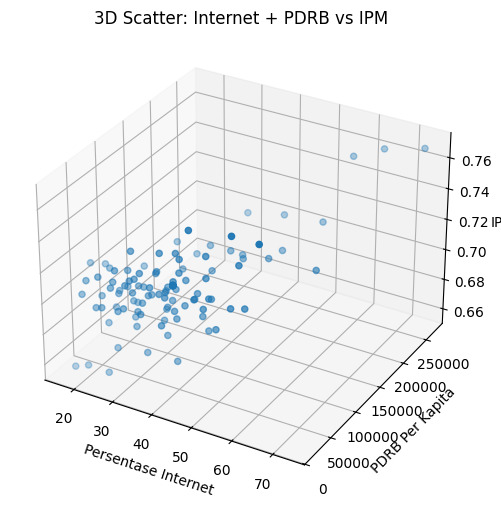

In [43]:
from mpl_toolkits.mplot3d import Axes3D
X3 = sm.add_constant(df[["persentase_internet", "pdrb_perkapita_dalam_ribu_rupiah"]])
model3 = sm.OLS(y, X3).fit()
print("\n=== MODEL 3 (Utama) ===")
print(model3.summary())

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df["persentase_internet"],
           df["pdrb_perkapita_dalam_ribu_rupiah"],
           df["ipm"])

ax.set_xlabel("Persentase Internet")
ax.set_ylabel("PDRB Per Kapita")
ax.set_zlabel("IPM")
plt.title("3D Scatter: Internet + PDRB vs IPM")

plt.show()

## **INTERPRETASI MODEL 3**

In [44]:
coef_int = model3.params["persentase_internet"]
coef_pdrb = model3.params["pdrb_perkapita_dalam_ribu_rupiah"]
p_int = model3.pvalues["persentase_internet"]
p_pdrb = model3.pvalues["pdrb_perkapita_dalam_ribu_rupiah"]
r2 = model3.rsquared
intercept = model3.params["const"]

print("=== INTERPRETASI MODEL 3 ===\n")

print(f"R-squared: {r2:.3f}")
print(f"Koefisien Internet: {coef_int:.5f}")
print(f"Koefisien PDRB: {coef_pdrb:.10f}")
print(f"p-value Internet: {p_int:.5f}")
print(f"p-value PDRB: {p_pdrb:.5f}")
print(f"Intercept: {intercept:.5f}\n")

interpretasi3 = f"""
Berdasarkan Model 3 (Regresi Berganda: Internet & PDRB → IPM):
1. Nilai R-squared sebesar {r2:.3f} menunjukkan bahwa sekitar {r2*100:.1f}% variasi IPM
   dapat dijelaskan oleh kombinasi dua variabel: persentase pengguna internet dan PDRB per kapita.
   Nilai R² ini adalah yang tertinggi dibandingkan Model 1 dan Model 2,
   sehingga Model 3 merupakan model terbaik untuk menjelaskan perubahan IPM.
2. Koefisien Internet = {coef_int:.5f} (positif), artinya:
   - setiap kenaikan 1% pengguna internet akan meningkatkan IPM sebesar {coef_int:.5f}
     dengan asumsi PDRB tetap.
   - pengaruh ini signifikan secara statistik (p-value = {p_int:.5f} < 0.05).
3. Koefisien PDRB per kapita = {coef_pdrb:.10f} (positif), artinya:
   - setiap kenaikan Rp 1.000 pada PDRB per kapita akan meningkatkan IPM sebesar {coef_pdrb:.10f},
     dengan asumsi internet tetap.
   - pengaruh ini juga signifikan (p-value = {p_pdrb:.5f} < 0.05).
4. Kedua variabel bersama-sama memberikan kontribusi positif terhadap IPM:
   - Internet mendukung peningkatan kualitas SDM melalui akses pendidikan, informasi, dan teknologi.
   - PDRB mendukung peningkatan layanan kesehatan, pendidikan, serta daya beli masyarakat.
5. Intercept sebesar {intercept:.5f} mengindikasikan nilai IPM dasar ketika kedua variabel = 0,
   meskipun kondisi tersebut tidak realistis dalam konteks nyata.
Kesimpulan:
✔ Model 3 adalah model paling kuat dalam menjelaskan IPM.
✔ Baik internet maupun PDRB berpengaruh positif dan signifikan.
✔ Teknologi dan ekonomi terbukti saling melengkapi dalam mempengaruhi pembangunan manusia.
"""

print(interpretasi3)

=== INTERPRETASI MODEL 3 ===

R-squared: 0.417
Koefisien Internet: 0.00078
Koefisien PDRB: 0.0000001276
p-value Internet: 0.00001
p-value PDRB: 0.00295
Intercept: 0.67663


Berdasarkan Model 3 (Regresi Berganda: Internet & PDRB → IPM):
1. Nilai R-squared sebesar 0.417 menunjukkan bahwa sekitar 41.7% variasi IPM
   dapat dijelaskan oleh kombinasi dua variabel: persentase pengguna internet dan PDRB per kapita.
   Nilai R² ini adalah yang tertinggi dibandingkan Model 1 dan Model 2,
   sehingga Model 3 merupakan model terbaik untuk menjelaskan perubahan IPM.
2. Koefisien Internet = 0.00078 (positif), artinya:
   - setiap kenaikan 1% pengguna internet akan meningkatkan IPM sebesar 0.00078
     dengan asumsi PDRB tetap.
   - pengaruh ini signifikan secara statistik (p-value = 0.00001 < 0.05).
3. Koefisien PDRB per kapita = 0.0000001276 (positif), artinya:
   - setiap kenaikan Rp 1.000 pada PDRB per kapita akan meningkatkan IPM sebesar 0.0000001276,
     dengan asumsi internet tetap.
   - pen

DIAGNOSTIK MODEL 3

1. MULTIKOLINEARITAS (VIF)


,Variabel,VIF
0,const,13.781769
1,persentase_internet,1.630178
2,pdrb_perkapita_dalam_ribu_rupiah,1.630178


Interpretasi:
- VIF < 5  : tidak terdapat masalah multikolinearitas yang serius.
- VIF >= 5 : terdapat indikasi multikolinearitas.

2. HETEROSKEDASTISITAS (Breusch-Pagan)
LM Statistic : 12.7120
p-value      : 0.0017
Kesimpulan   : Terdapat indikasi heteroskedastisitas.

3. NORMALITAS RESIDUAL (Shapiro-Wilk)
Statistic : 0.9728
p-value   : 0.0201
Kesimpulan : Residual tidak berdistribusi normal.



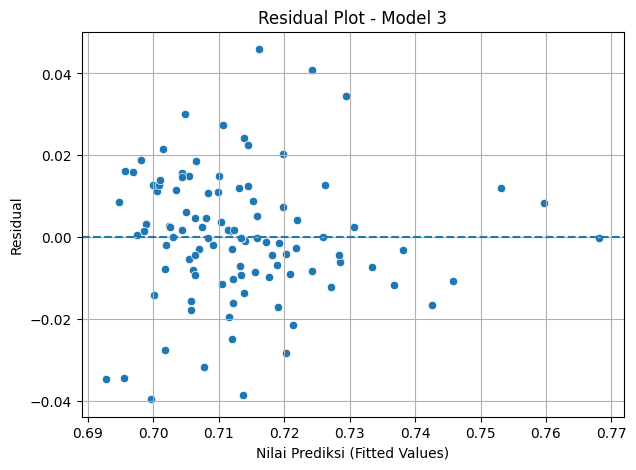

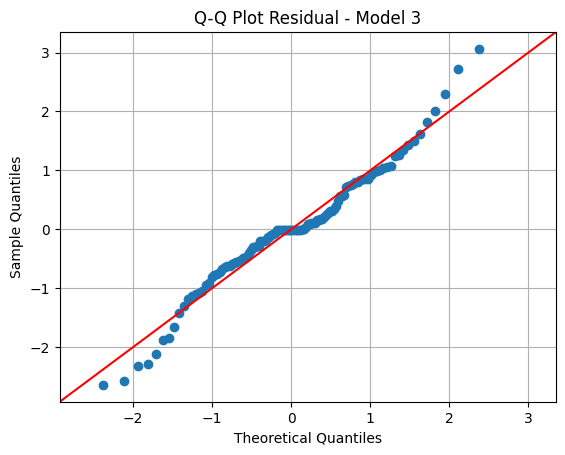

In [45]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

X_diag = df[[
    "persentase_internet",
    "pdrb_perkapita_dalam_ribu_rupiah"
]].copy()

X_diag = sm.add_constant(X_diag)

residual = model3.resid
fitted = model3.fittedvalues

print("==========================================")
print("DIAGNOSTIK MODEL 3")
print("==========================================\n")

vif = pd.DataFrame()
vif["Variabel"] = X_diag.columns
vif["VIF"] = [
    variance_inflation_factor(X_diag.values, i)
    for i in range(X_diag.shape[1])
]

print("1. MULTIKOLINEARITAS (VIF)")
display(vif)

print("Interpretasi:")
print("- VIF < 5  : tidak terdapat masalah multikolinearitas yang serius.")
print("- VIF >= 5 : terdapat indikasi multikolinearitas.\n")


bp_test = het_breuschpagan(residual, X_diag)

bp_stat = bp_test[0]
bp_pvalue = bp_test[1]

print("2. HETEROSKEDASTISITAS (Breusch-Pagan)")
print(f"LM Statistic : {bp_stat:.4f}")
print(f"p-value      : {bp_pvalue:.4f}")

if bp_pvalue > 0.05:
    print("Kesimpulan   : Tidak terdapat indikasi heteroskedastisitas.")
else:
    print("Kesimpulan   : Terdapat indikasi heteroskedastisitas.")

print()

shapiro_stat, shapiro_pvalue = shapiro(residual)

print("3. NORMALITAS RESIDUAL (Shapiro-Wilk)")
print(f"Statistic : {shapiro_stat:.4f}")
print(f"p-value   : {shapiro_pvalue:.4f}")

if shapiro_pvalue > 0.05:
    print("Kesimpulan : Residual berdistribusi normal.")
else:
    print("Kesimpulan : Residual tidak berdistribusi normal.")

print()

plt.figure(figsize=(7, 5))
sns.scatterplot(x=fitted, y=residual)
plt.axhline(0, linestyle="--")
plt.xlabel("Nilai Prediksi (Fitted Values)")
plt.ylabel("Residual")
plt.title("Residual Plot - Model 3")
plt.grid(True)
plt.show()

import statsmodels.api as sm

sm.qqplot(residual, line="45", fit=True)
plt.title("Q-Q Plot Residual - Model 3")
plt.grid(True)
plt.show()

In [46]:
model3_robust = model3.get_robustcov_results(cov_type="HC3")

print("=== MODEL 3 DENGAN ROBUST STANDARD ERROR (HC3) ===")
print(model3_robust.summary())

=== MODEL 3 DENGAN ROBUST STANDARD ERROR (HC3) ===
                            OLS Regression Results                            
Dep. Variable:                    ipm   R-squared:                       0.417
Model:                            OLS   Adj. R-squared:                  0.406
Method:                 Least Squares   F-statistic:                     53.38
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           5.72e-17
Time:                        20:19:13   Log-Likelihood:                 317.02
No. Observations:                 114   AIC:                            -628.0
Df Residuals:                     111   BIC:                            -619.8
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

In [47]:
print("==========================================")
print("HASIL FINAL MODEL 3")
print("==========================================")

print(f"R-squared                 : {model3.rsquared:.3f}")
print(f"Adjusted R-squared        : {model3.rsquared_adj:.3f}")

print(f"\nInternet:")
print(f"  Koefisien               : {model3_robust.params[1]:.7f}")
print(f"  p-value (HC3)           : {model3_robust.pvalues[1]:.5f}")

print(f"\nPDRB per Kapita:")
print(f"  Koefisien               : {model3_robust.params[2]:.10f}")
print(f"  p-value (HC3)           : {model3_robust.pvalues[2]:.5f}")

print("\nKesimpulan:")
print("- Model menggunakan standard error robust HC3.")
print("- Internet berpengaruh positif dan signifikan terhadap IPM.")
print("- PDRB per kapita berpengaruh positif dan signifikan terhadap IPM.")
print("- Tidak terdapat multikolinearitas serius berdasarkan VIF.")

HASIL FINAL MODEL 3
R-squared                 : 0.417
Adjusted R-squared        : 0.406

Internet:
  Koefisien               : 0.0007804
  p-value (HC3)           : 0.00178

PDRB per Kapita:
  Koefisien               : 0.0000001276
  p-value (HC3)           : 0.00937

Kesimpulan:
- Model menggunakan standard error robust HC3.
- Internet berpengaruh positif dan signifikan terhadap IPM.
- PDRB per kapita berpengaruh positif dan signifikan terhadap IPM.
- Tidak terdapat multikolinearitas serius berdasarkan VIF.


## **Refrensi**



1.   Gagolewski, M. (n.d.). *Chapter 430: Group by — Minimalist Data Wrangling with Python*. Retrieved [November 17, 2025], from https://datawranglingpy.gagolewski.com/chapter/430-group-by.html
1.   Google Colab Notebook. *Data Wrangling Pertemuan 7*. Retrieved [November 17, 2025], from https://colab.research.google.com/drive/1LyRfQ7K5W8Ny095bJjZhozEIYtj6w-Uj?usp=sharing
2.   Google Colab Notebook. *Data Wrangling Pertemuan 8*. Retrieved [November 17, 2025], from https://colab.research.google.com/drive/1d0B-hiTpeVmhgDrqbHxqTPqy7tpt8mtV?usp=sharing#scrollTo=hs6cfP2AH_bC

1.   Badan Pusat Statistik. (n.d.).  [November 16, 2025], from https://www.bps.go.id/id/statistics-table/2/MTIyNSMy/proporsi-individu-yang-menggunakan-internet-menurut-provinsi.html
2.   Global Data Lab. (n.d.). *Subnational Human Development Index (SHDI) – Indonesia*.  [November 16, 2025], from https://globaldatalab.org/shdi/table/shdi/IDN/?levels=1+4&years=2019+2018+2017&interpolation=0&extrapolation=

1.   Open Data Jabar. (n.d.). *Produk Domestik Regional Bruto (PDRB) per kapita berdasarkan provinsi*.  [November 16, 2025], from https://opendata.jabarprov.go.id/id/dataset/produk-domestik-regional-bruto-pdrb-per-kapita--atas-dasar-harga-berlaku-berdasarkan-provinsi-di-indonesia


